# Netflix Movies and TV Shows — Exploratory Data Analysis (EDA)

### CodeAlpha Data Analytics Internship

**Objective:**  
To explore and analyze the Netflix titles dataset using Python, Pandas, Matplotlib, and Seaborn.

**Key Areas of Analysis:**
- Content Type Distribution
- Release Year Trends
- Country Analysis
- Genre Analysis
- Rating Analysis
- Movie Duration
- TV Show Seasons
- Netflix Content Addition Trends
- Data Quality Analysis

In [7]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape:
(8807, 12)

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64


In [42]:
# Data Quality Check

print("Dataset Shape:", df.shape)

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nInvalid Rating Values:")
print(
    df[df["rating"].str.contains("min", na=False)][
        ["title", "rating", "duration"]
    ]
)

Dataset Shape: (8807, 13)

Duplicate Rows: 0

Missing Values:
show_id                0
type                   0
title                  0
director            2634
cast                 825
country              831
date_added            10
release_year           0
rating                 4
duration               3
listed_in              0
description            0
date_added_clean      98
dtype: int64

Invalid Rating Values:
                                     title  rating duration
5541                       Louis C.K. 2017  74 min      NaN
5794                 Louis C.K.: Hilarious  84 min      NaN
5813  Louis C.K.: Live at the Comedy Store  66 min      NaN


In [43]:
# Create a clean copy for further analysis

df_clean = df.copy()

# Fix the 3 incorrect rating values
invalid_rating = df_clean["rating"].str.contains("min", na=False)

df_clean.loc[invalid_rating, "duration"] = df_clean.loc[invalid_rating, "rating"]
df_clean.loc[invalid_rating, "rating"] = pd.NA

print("Cleaned Records:")
print(
    df_clean.loc[invalid_rating, ["title", "rating", "duration"]]
)

Cleaned Records:
                                     title rating duration
5541                       Louis C.K. 2017    NaN   74 min
5794                 Louis C.K.: Hilarious    NaN   84 min
5813  Louis C.K.: Live at the Comedy Store    NaN   66 min


In [44]:
print("Original Dataset Shape:", df.shape)
print("Clean Dataset Shape:", df_clean.shape)

print("\nRemaining Invalid Rating Values:")
print(
    df_clean[df_clean["rating"].str.contains("min", na=False)]
)

print("\nDuplicate Rows:", df_clean.duplicated().sum())

Original Dataset Shape: (8807, 13)
Clean Dataset Shape: (8807, 13)

Remaining Invalid Rating Values:
Empty DataFrame
Columns: [show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description, date_added_clean]
Index: []

Duplicate Rows: 0


In [8]:
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
print(missing_percentage.round(2))

Missing Value Percentage:
show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64


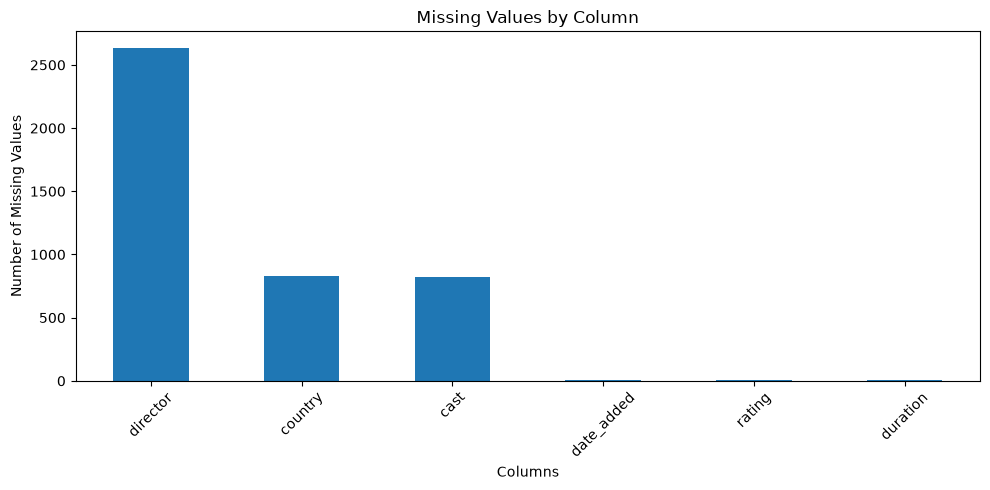

In [10]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing.plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../Charts/missing_values.png")
plt.show()

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
print("Unique values in Type:")
print(df["type"].value_counts())

print("\nUnique values in Rating:")
print(df["rating"].value_counts())

Unique values in Type:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Unique values in Rating:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [13]:
invalid_rating = df[df["rating"].str.contains("min", na=False)]

print(invalid_rating[["title", "type", "rating", "duration"]])

                                     title   type  rating duration
5541                       Louis C.K. 2017  Movie  74 min      NaN
5794                 Louis C.K.: Hilarious  Movie  84 min      NaN
5813  Louis C.K.: Live at the Comedy Store  Movie  66 min      NaN


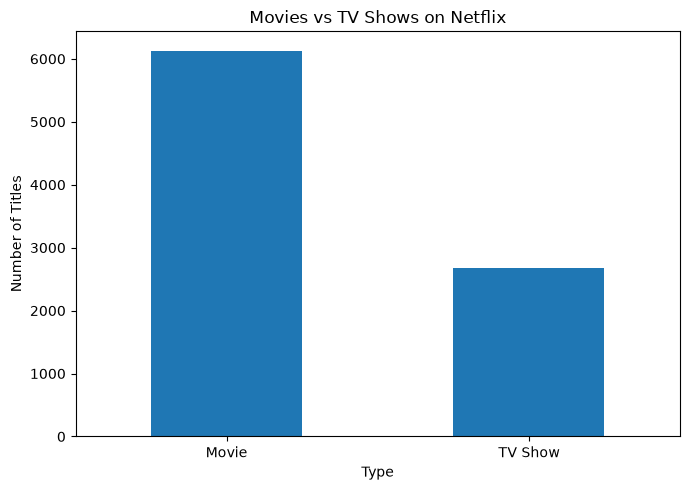

In [14]:
import matplotlib.pyplot as plt

type_counts = df["type"].value_counts()

plt.figure(figsize=(7, 5))
type_counts.plot(kind="bar")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../Charts/movies_vs_tv_shows.png")
plt.show()

In [15]:
type_percentage = df["type"].value_counts(normalize=True) * 100

print("Percentage Distribution:")
print(type_percentage.round(2))

Percentage Distribution:
type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


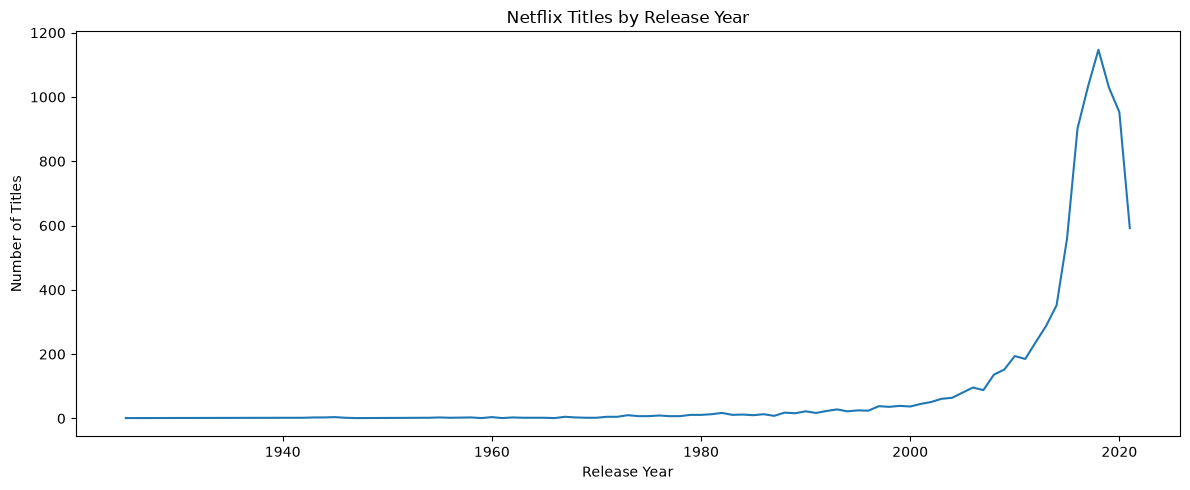

In [16]:
release_year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
release_year_counts.plot(kind="line")

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()

plt.savefig("../Charts/release_year_trend.png")
plt.show()

In [17]:
peak_year = df["release_year"].value_counts().idxmax()
peak_count = df["release_year"].value_counts().max()

print("Year with the most titles:", peak_year)
print("Number of titles:", peak_count)

Year with the most titles: 2018
Number of titles: 1147


In [18]:
country_counts = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

print("Top 10 Countries:")
print(country_counts.head(10))

Top 10 Countries:
country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


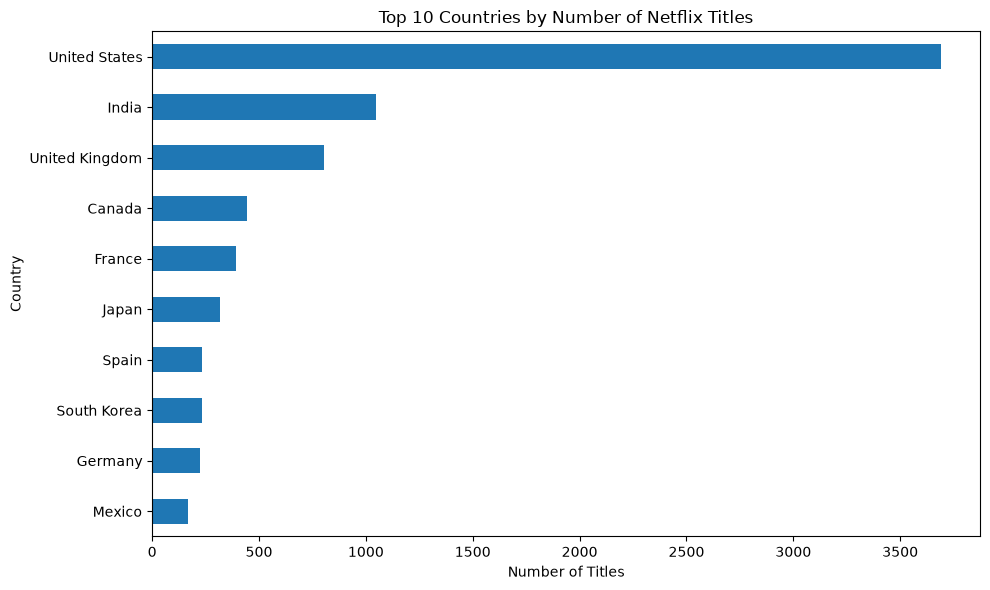

In [19]:
top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))
top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig("../Charts/top_10_countries.png")
plt.show()

In [20]:
genre_counts = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

print("Top 10 Genres:")
print(genre_counts.head(10))

Top 10 Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


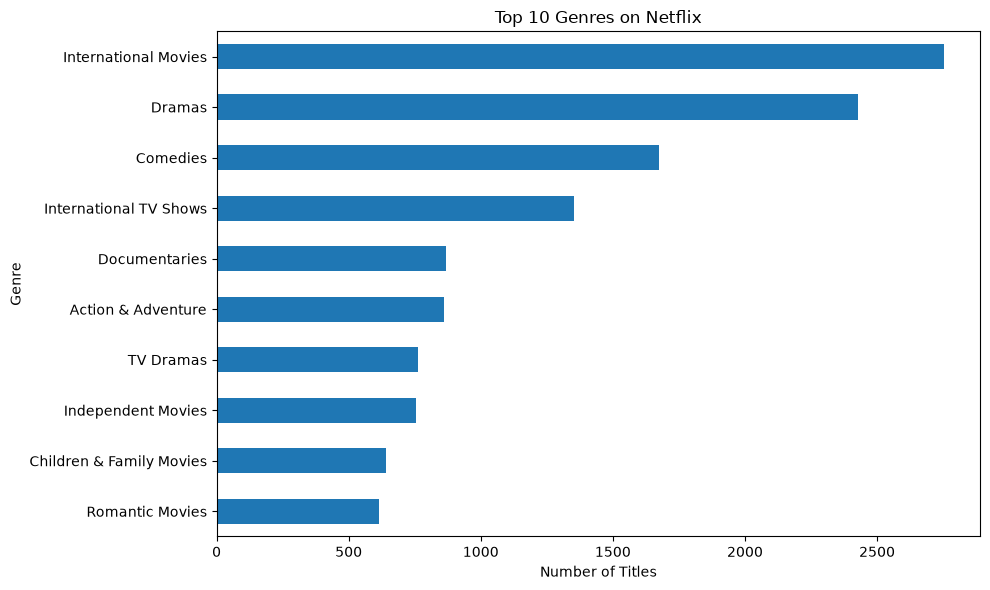

In [21]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))
top_genres.sort_values().plot(kind="barh")

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()

plt.savefig("../Charts/top_10_genres.png")
plt.show()

In [22]:
movie_duration = df[df["type"] == "Movie"]["duration"].dropna()

movie_duration = movie_duration.str.replace(" min", "", regex=False).astype(int)

print("Average Movie Duration:", round(movie_duration.mean(), 2), "minutes")
print("Shortest Movie:", movie_duration.min(), "minutes")
print("Longest Movie:", movie_duration.max(), "minutes")

Average Movie Duration: 99.58 minutes
Shortest Movie: 3 minutes
Longest Movie: 312 minutes


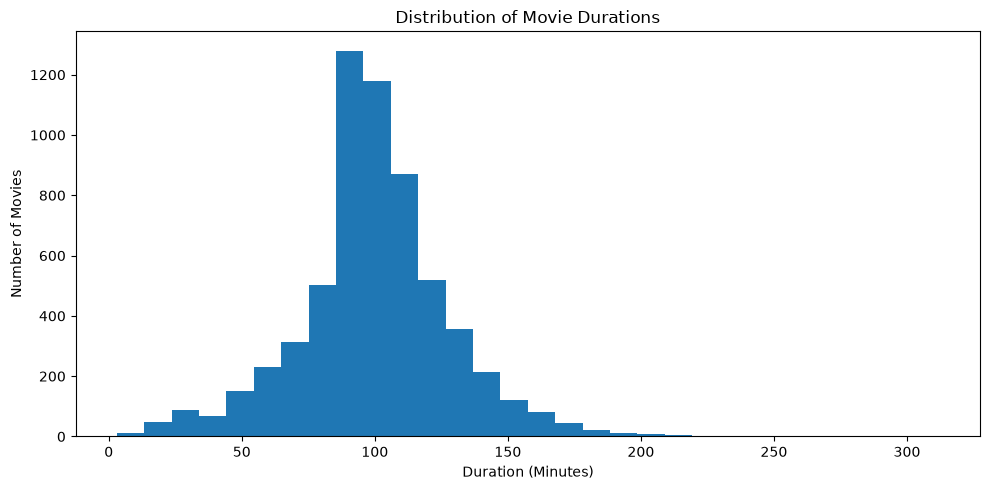

In [23]:
plt.figure(figsize=(10, 5))

plt.hist(movie_duration, bins=30)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()

plt.savefig("../Charts/movie_duration_distribution.png")
plt.show()

In [24]:
print("Median Movie Duration:", movie_duration.median(), "minutes")
print("Q1 (25th percentile):", movie_duration.quantile(0.25), "minutes")
print("Q3 (75th percentile):", movie_duration.quantile(0.75), "minutes")

Median Movie Duration: 98.0 minutes
Q1 (25th percentile): 87.0 minutes
Q3 (75th percentile): 114.0 minutes


In [25]:
Q1 = movie_duration.quantile(0.25)
Q3 = movie_duration.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = movie_duration[
    (movie_duration < lower_bound) |
    (movie_duration > upper_bound)
]

print("Potential Outliers:", len(outliers))

IQR: 27.0
Lower Bound: 46.5
Upper Bound: 154.5
Potential Outliers: 450


In [26]:
short_outliers = movie_duration[movie_duration < lower_bound]
long_outliers = movie_duration[movie_duration > upper_bound]

print("Short-duration potential outliers:", len(short_outliers))
print("Long-duration potential outliers:", len(long_outliers))

print("\nShortest potential outlier:")
print(short_outliers.min())

print("\nLongest potential outlier:")
print(long_outliers.max())

Short-duration potential outliers: 249
Long-duration potential outliers: 201

Shortest potential outlier:
3

Longest potential outlier:
312


In [27]:
tv_duration = df[df["type"] == "TV Show"]["duration"].dropna()

print("TV Show Duration Distribution:")
print(tv_duration.value_counts().sort_index())

TV Show Duration Distribution:
duration
1 Season      1793
10 Seasons       7
11 Seasons       2
12 Seasons       2
13 Seasons       3
15 Seasons       2
17 Seasons       1
2 Seasons      425
3 Seasons      199
4 Seasons       95
5 Seasons       65
6 Seasons       33
7 Seasons       23
8 Seasons       17
9 Seasons        9
Name: count, dtype: int64


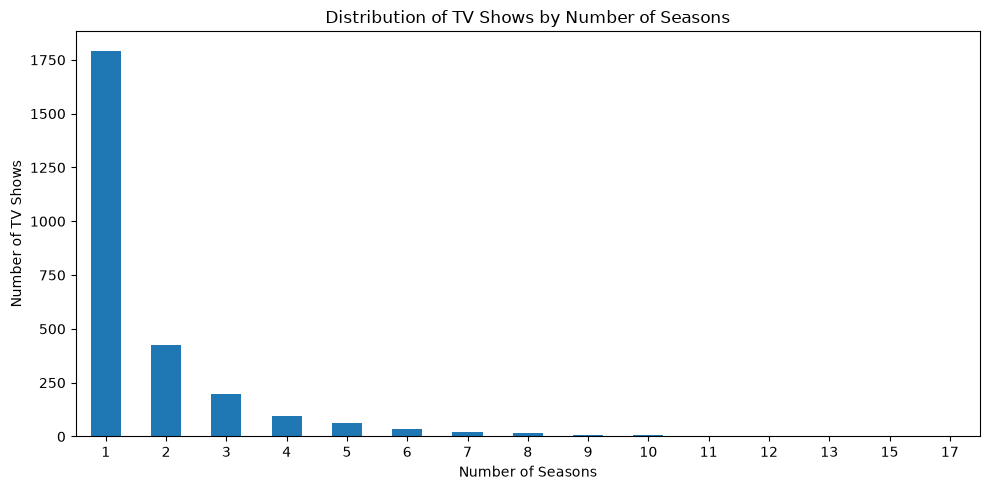

In [28]:
tv_season_counts = (
    tv_duration
    .str.replace(" Seasons", "", regex=False)
    .str.replace(" Season", "", regex=False)
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

tv_season_counts.plot(kind="bar")

plt.title("Distribution of TV Shows by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../Charts/tv_show_seasons.png")
plt.show()

In [29]:
df["date_added_clean"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

print("Date Added Range:")
print("From:", df["date_added_clean"].min())
print("To:", df["date_added_clean"].max())

Date Added Range:
From: 2008-01-01 00:00:00
To: 2021-09-25 00:00:00


In [30]:
added_by_year = df["date_added_clean"].dt.year.value_counts().sort_index()

print("Titles Added by Year:")
print(added_by_year)

Titles Added by Year:
date_added_clean
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


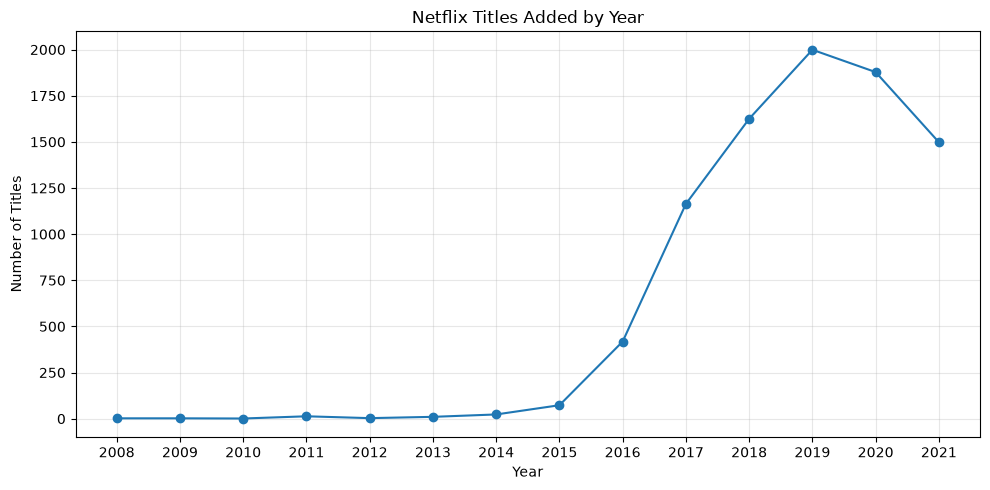

In [31]:
plt.figure(figsize=(10, 5))

added_by_year.plot(kind="line", marker="o")

plt.title("Netflix Titles Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(added_by_year.index.astype(int))
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("../Charts/titles_added_by_year.png")
plt.show()

In [32]:
added_by_type_year = (
    df.groupby([df["date_added_clean"].dt.year, "type"])
      .size()
      .unstack(fill_value=0)
)

print(added_by_type_year)

type              Movie  TV Show
date_added_clean                
2008.0                1        1
2009.0                2        0
2010.0                1        0
2011.0               13        0
2012.0                3        0
2013.0                6        4
2014.0               19        4
2015.0               56       17
2016.0              253      165
2017.0              839      325
2018.0             1237      388
2019.0             1424      575
2020.0             1284      594
2021.0              993      505


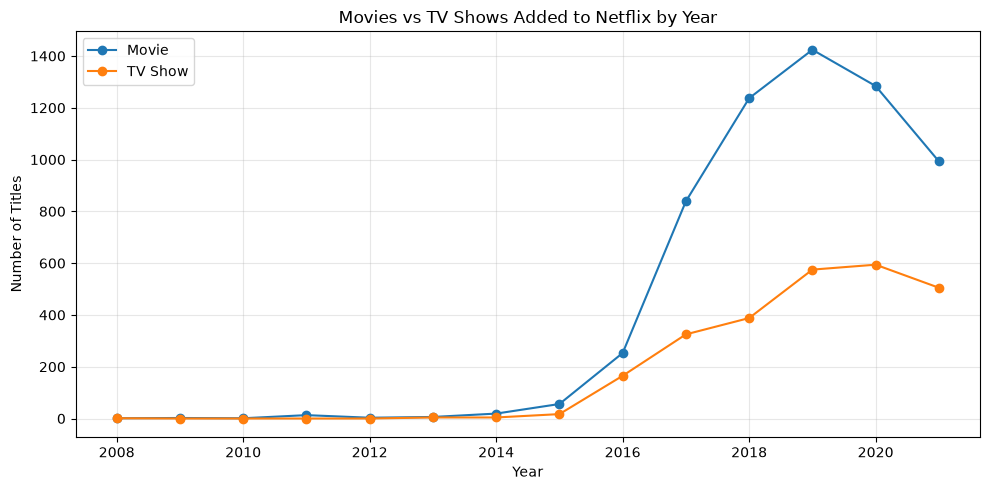

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    added_by_type_year.index,
    added_by_type_year["Movie"],
    marker="o",
    label="Movie"
)

plt.plot(
    added_by_type_year.index,
    added_by_type_year["TV Show"],
    marker="o",
    label="TV Show"
)

plt.title("Movies vs TV Shows Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("../Charts/movies_vs_tv_added_by_year.png")
plt.show()

In [34]:
rating_counts = (
    df[~df["rating"].str.contains("min", na=False)]
    ["rating"]
    .value_counts()
)

print("Rating Distribution:")
print(rating_counts)

Rating Distribution:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


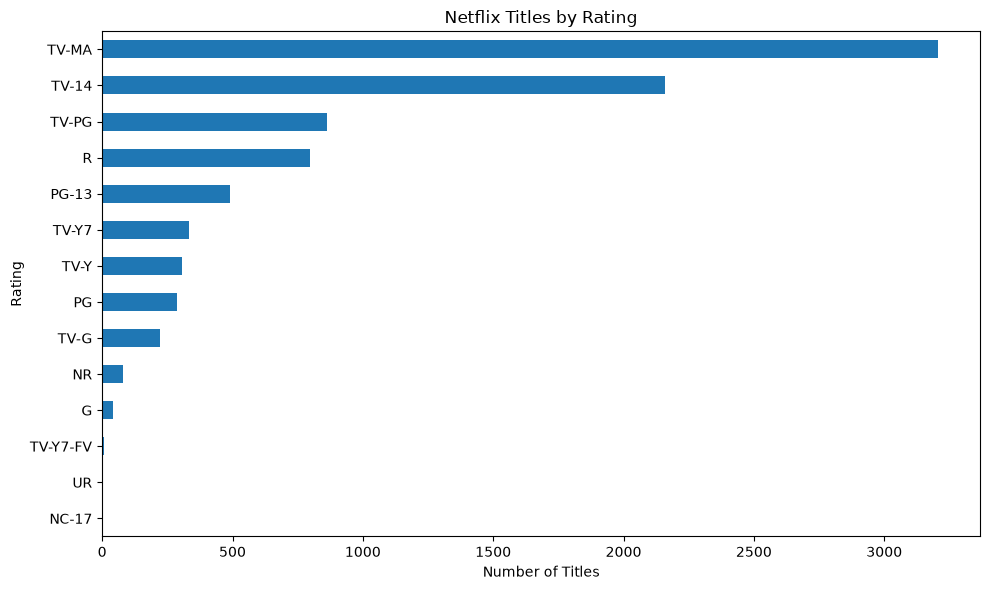

In [35]:
plt.figure(figsize=(10, 6))

rating_counts.sort_values().plot(kind="barh")

plt.title("Netflix Titles by Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.tight_layout()

plt.savefig("../Charts/rating_distribution.png")
plt.show()

In [36]:
rating_type = (
    df[~df["rating"].str.contains("min", na=False)]
    .groupby(["rating", "type"])
    .size()
    .unstack(fill_value=0)
)

print(rating_type)

type      Movie  TV Show
rating                  
G            41        0
NC-17         3        0
NR           75        5
PG          287        0
PG-13       490        0
R           797        2
TV-14      1427      733
TV-G        126       94
TV-MA      2062     1145
TV-PG       540      323
TV-Y        131      176
TV-Y7       139      195
TV-Y7-FV      5        1
UR            3        0


<Figure size 1200x600 with 0 Axes>

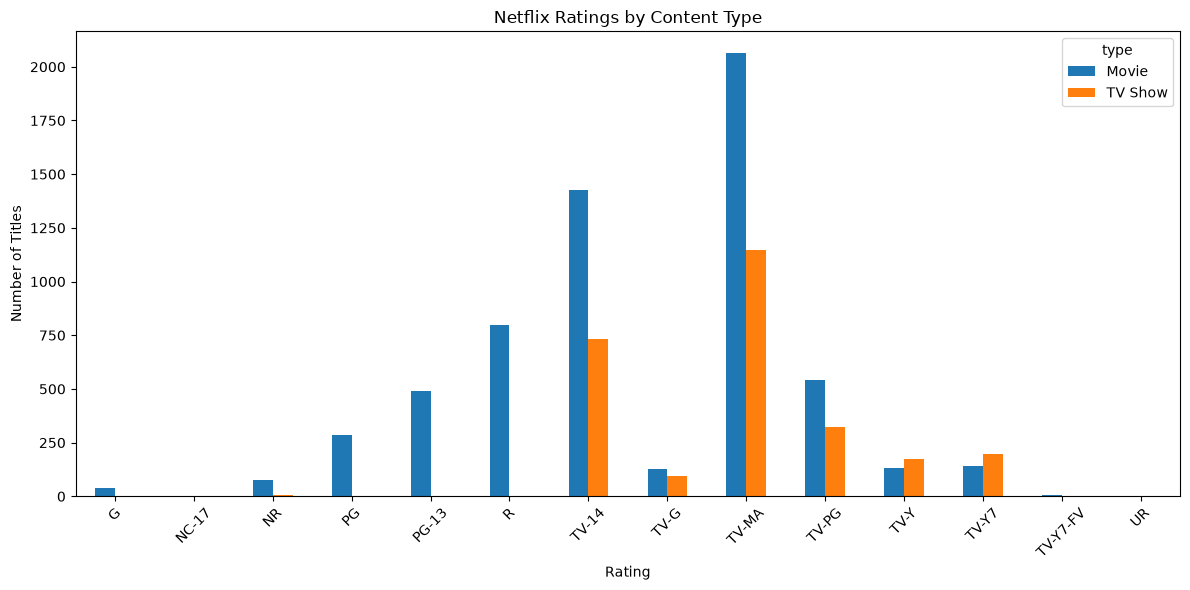

In [37]:
plt.figure(figsize=(12, 6))

rating_type.plot(kind="bar", figsize=(12, 6))

plt.title("Netflix Ratings by Content Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../Charts/rating_by_type.png")
plt.show()

In [38]:
year_type = (
    df.groupby(["release_year", "type"])
    .size()
    .unstack(fill_value=0)
)

print(year_type.tail(10))

type          Movie  TV Show
release_year                
2012            173       64
2013            225       63
2014            264       88
2015            398      162
2016            658      244
2017            767      265
2018            767      380
2019            633      397
2020            517      436
2021            277      315


<Figure size 1200x600 with 0 Axes>

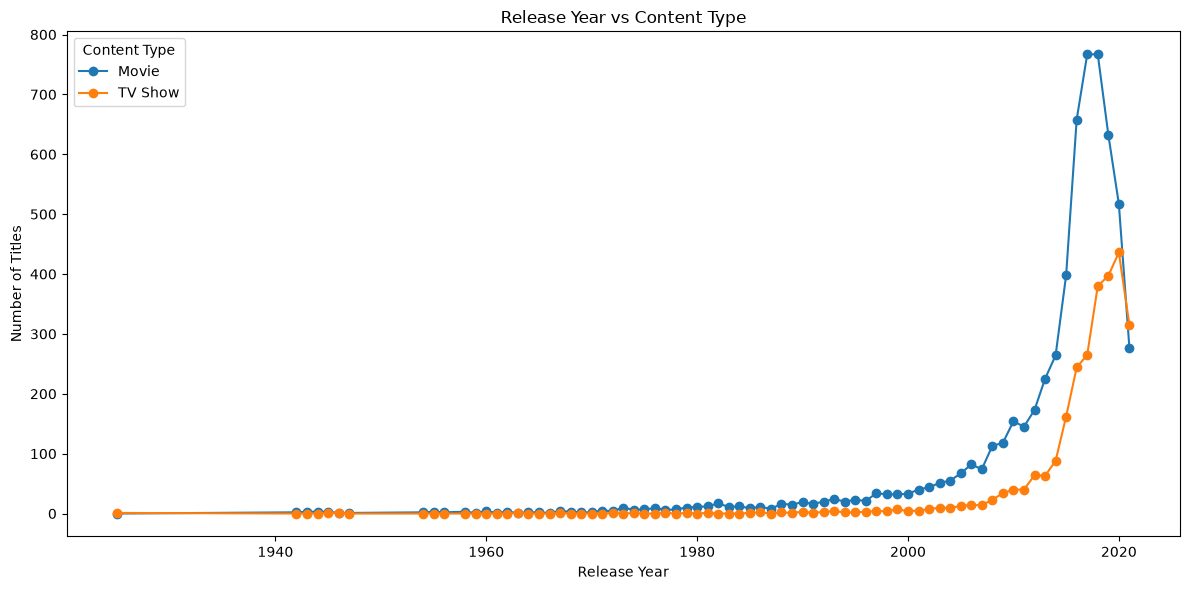

In [39]:
plt.figure(figsize=(12, 6))

year_type.plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)

plt.title("Release Year vs Content Type")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")

plt.tight_layout()

plt.savefig("../Charts/release_year_by_type.png")
plt.show()

In [40]:
genre_type = (
    df.dropna(subset=["listed_in"])
    .assign(genre=df["listed_in"].str.split(", "))
    .explode("genre")
    .groupby(["genre", "type"])
    .size()
    .unstack(fill_value=0)
)

top_genres = genre_type.sum(axis=1).sort_values(ascending=False).head(10)

genre_type_top10 = genre_type.loc[top_genres.index]

print(genre_type_top10)

type                      Movie  TV Show
genre                                   
International Movies       2752        0
Dramas                     2427        0
Comedies                   1674        0
International TV Shows        0     1351
Documentaries               869        0
Action & Adventure          859        0
TV Dramas                     0      763
Independent Movies          756        0
Children & Family Movies    641        0
Romantic Movies             616        0


<Figure size 1200x600 with 0 Axes>

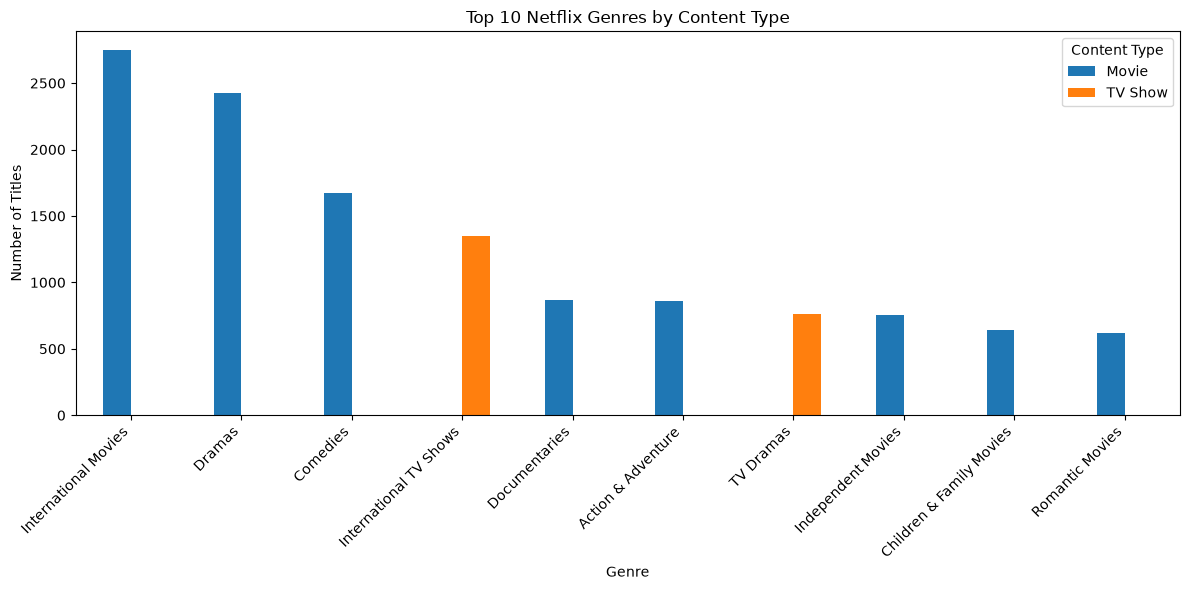

In [41]:
plt.figure(figsize=(12, 6))

genre_type_top10.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Top 10 Netflix Genres by Content Type")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Content Type")

plt.tight_layout()

plt.savefig("../Charts/top_10_genres_by_type.png")
plt.show()

# Key Insights

## 1. Content Type
- The dataset contains 8,807 Netflix titles.
- Movies are the majority of the dataset, with 6,131 titles.
- TV Shows account for 2,676 titles.

## 2. Release Year
- The highest number of titles in the dataset were released in 2018.
- The number of TV Shows increased considerably in the later release years.
- Release year represents the original release year, not the year the title was added to Netflix.

## 3. Top Countries
- The United States has the highest number of associated titles.
- India is the second-highest country in the country analysis.
- Country counts are not mutually exclusive because a title can be associated with multiple countries.

## 4. Genres
- International Movies, Dramas, and Comedies are among the most common categories.
- TV-specific categories such as International TV Shows and TV Dramas are also prominent.
- A title can belong to multiple genres.

## 5. Ratings
- TV-MA is the most common rating in the dataset.
- TV-14 is the second most common rating.
- Movie-specific ratings such as PG, PG-13, and R are mainly associated with Movies.
- TV-Y and TV-Y7 are more commonly associated with TV Shows.

## 6. Movie Duration
- The average movie duration is approximately 99.6 minutes.
- The median duration is approximately 98 minutes.
- Most movies fall within a relatively moderate duration range.

## 7. TV Show Seasons
- Most TV Shows have only one season.
- The number of titles generally decreases as the number of seasons increases.

## 8. Titles Added to Netflix
- The number of titles added to Netflix increased substantially after 2015.
- 2019 had the highest number of titles added in this dataset.
- The dataset ends on September 25, 2021, so 2021 represents a partial year.

## 9. Data Quality
- No duplicate rows were found.
- Missing values are present in columns such as director, cast, country, date_added, rating, and duration.
- Three records contain duration values incorrectly stored in the rating column (`74 min`, `84 min`, and `66 min`).
- These data-quality issues should be considered before further analysis.